In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/home/aman/Downloads/car data.xls')

# EDA 

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [5]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

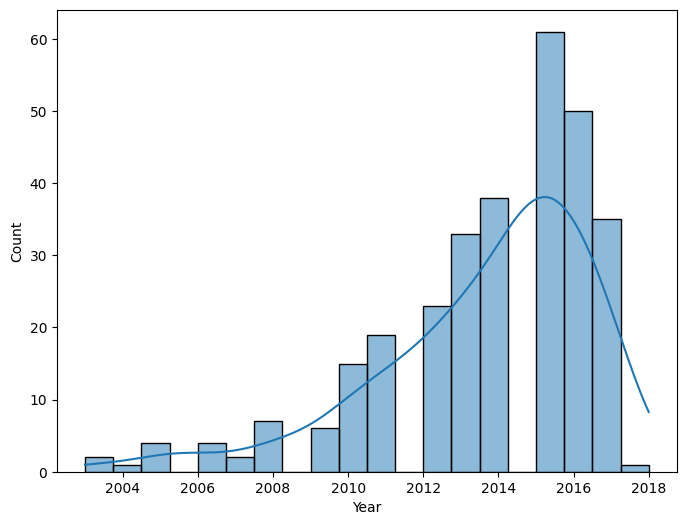

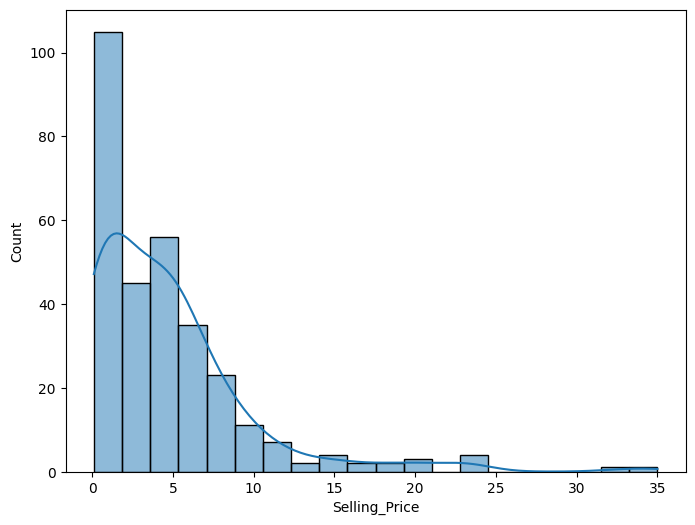

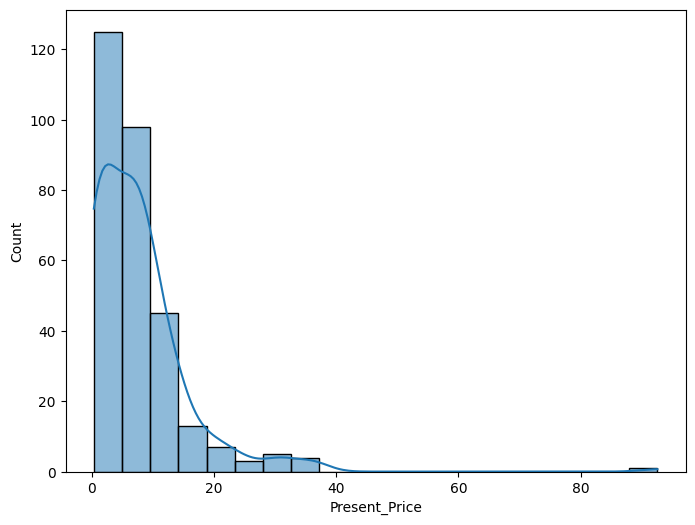

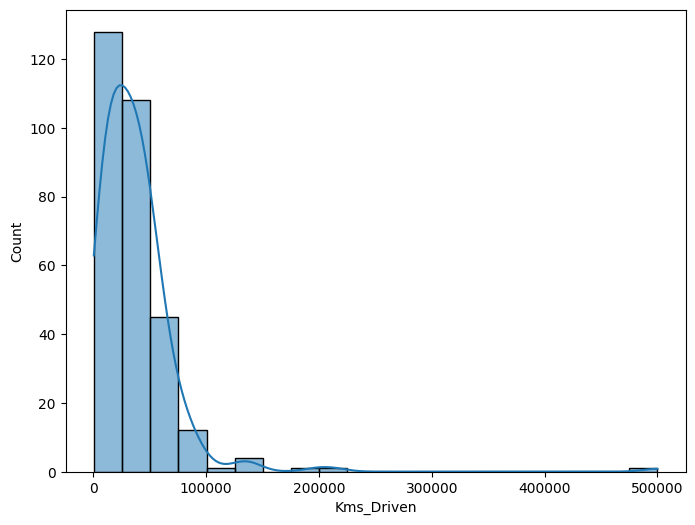

In [6]:
nv = ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven']
for col in nv:
  plt.figure(figsize= (8,6))
  sns.histplot(df[col], kde = True, bins= 20)

<Axes: xlabel='Owner', ylabel='count'>

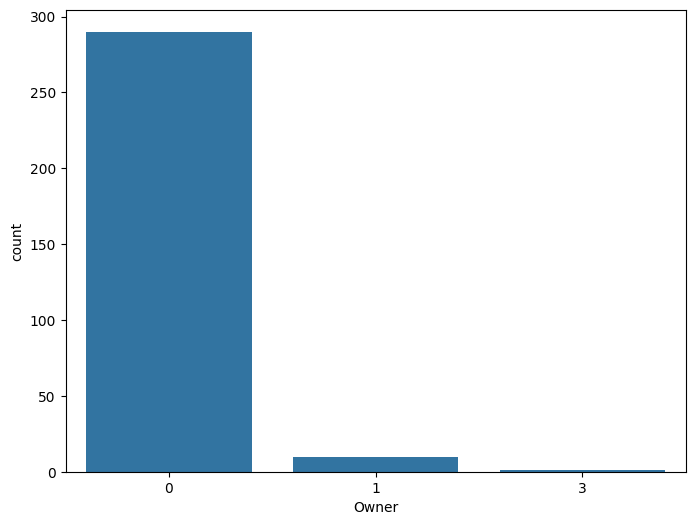

In [7]:
plt.figure(figsize= (8,6))
sns.countplot(x = df['Owner'], )

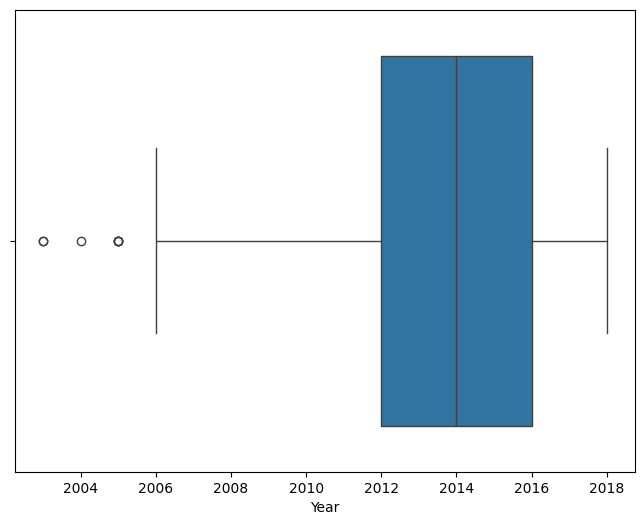

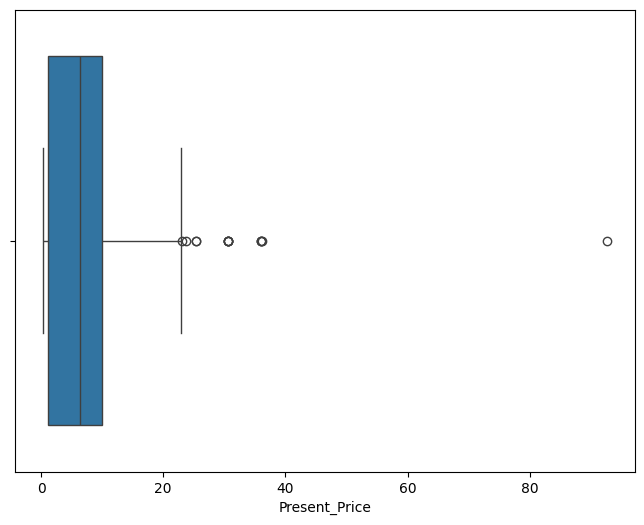

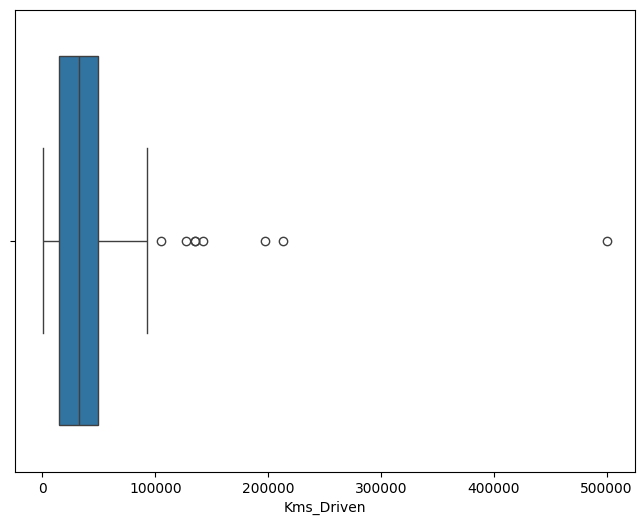

In [8]:
nv = ['Year', 'Present_Price', 'Kms_Driven']
for col in nv:
  plt.figure(figsize= (8,6))
  sns.boxplot(x = df[col])

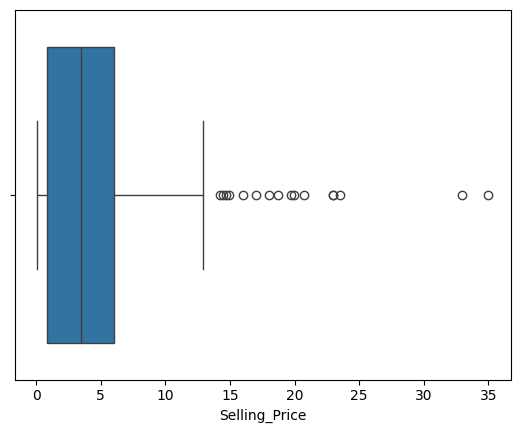

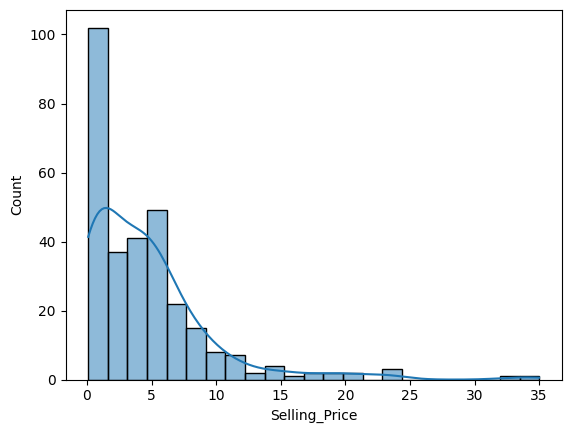

In [44]:
sns.boxplot(x=y)
plt.show()

sns.histplot(y, kde=True)
plt.show()

# Cleaning and Preprocessing

In [10]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [11]:
print(df.duplicated().sum())

2


In [12]:
df.drop_duplicates(inplace = True)

In [13]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [14]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

In [15]:
df['Seller_Type'].value_counts()

Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

In [16]:
df['Transmission'].value_counts()

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

In [17]:
df = pd.get_dummies(
    df,
    columns=['Seller_Type', 'Transmission', 'Fuel_Type'],
    drop_first=True
)

In [18]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Seller_Type_Individual,Transmission_Manual,Fuel_Type_Diesel,Fuel_Type_Petrol
0,ritz,2014,3.35,5.59,27000,0,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,False,True,True,False
2,ciaz,2017,7.25,9.85,6900,0,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,False,True,True,False


In [19]:
dummy_cols = ['Seller_Type_Individual',	'Transmission_Manual',	'Fuel_Type_Diesel',	'Fuel_Type_Petrol']

df[dummy_cols] = df[dummy_cols].astype(int)

In [20]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Seller_Type_Individual,Transmission_Manual,Fuel_Type_Diesel,Fuel_Type_Petrol
0,ritz,2014,3.35,5.59,27000,0,0,1,0,1
1,sx4,2013,4.75,9.54,43000,0,0,1,1,0
2,ciaz,2017,7.25,9.85,6900,0,0,1,0,1
3,wagon r,2011,2.85,4.15,5200,0,0,1,0,1
4,swift,2014,4.60,6.87,42450,0,0,1,1,0


In [21]:
df['Car_Name'].value_counts()

Car_Name
city                   26
corolla altis          16
verna                  14
fortuner               10
brio                   10
                       ..
Hero Super Splendor     1
Hero Hunk               1
Hero  Ignitor Disc      1
Hero  CBZ Xtreme        1
Bajaj  ct 100           1
Name: count, Length: 98, dtype: int64

In [22]:
df.drop('Car_Name', axis=1, inplace=True)

In [23]:
df

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Seller_Type_Individual,Transmission_Manual,Fuel_Type_Diesel,Fuel_Type_Petrol
0,2014,3.35,5.59,27000,0,0,1,0,1
1,2013,4.75,9.54,43000,0,0,1,1,0
2,2017,7.25,9.85,6900,0,0,1,0,1
3,2011,2.85,4.15,5200,0,0,1,0,1
4,2014,4.60,6.87,42450,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,0,1,1,0
297,2015,4.00,5.90,60000,0,0,1,0,1
298,2009,3.35,11.00,87934,0,0,1,0,1
299,2017,11.50,12.50,9000,0,0,1,1,0


# Feature Engineering and Extraction

In [24]:
df_scaled = df.copy()

In [25]:
df_scaled.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Seller_Type_Individual,Transmission_Manual,Fuel_Type_Diesel,Fuel_Type_Petrol
0,2014,3.35,5.59,27000,0,0,1,0,1
1,2013,4.75,9.54,43000,0,0,1,1,0
2,2017,7.25,9.85,6900,0,0,1,0,1
3,2011,2.85,4.15,5200,0,0,1,0,1
4,2014,4.60,6.87,42450,0,0,1,1,0


In [26]:
df_scaled['Car_Age'] = 2026 - df_scaled['Year']
df_scaled.drop('Year', axis=1, inplace=True)

In [27]:
df['Car_Age'] = 2026 - df['Year']
df.drop('Year', axis=1, inplace=True)

In [28]:
from sklearn.preprocessing import StandardScaler
col = ['Kms_Driven', 'Present_Price']
scaler = StandardScaler()
df_scaled[col] = scaler.fit_transform(df_scaled[col])

In [29]:
df_scaled.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Seller_Type_Individual,Transmission_Manual,Fuel_Type_Diesel,Fuel_Type_Petrol,Car_Age
0,3.35,-0.228097,-0.254603,0,0,1,0,1,12
1,4.75,0.233700,0.156181,0,0,1,1,0,13
2,7.25,0.269942,-0.770651,0,0,1,0,1,9
3,2.85,-0.396448,-0.814297,0,0,1,0,1,15
4,4.60,-0.078451,0.142061,0,0,1,1,0,12


In [30]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Seller_Type_Individual,Transmission_Manual,Fuel_Type_Diesel,Fuel_Type_Petrol,Car_Age
0,3.35,5.59,27000,0,0,1,0,1,12
1,4.75,9.54,43000,0,0,1,1,0,13
2,7.25,9.85,6900,0,0,1,0,1,9
3,2.85,4.15,5200,0,0,1,0,1,15
4,4.60,6.87,42450,0,0,1,1,0,12


In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

X = df_scaled.drop(columns='Selling_Price') 
y = df_scaled['Selling_Price']

model = LinearRegression()

scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [   0.87313976    0.77700214 -105.75161466    0.59049109    0.82883067]
Mean R2: -20.53643020178172


In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)


print("R2 Score:", r2_score(y_test, y_pred))


scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("CV Scores:", scores)
print("Mean CV R2:", np.mean(scores))

R2 Score: 0.5274594493012694
CV Scores: [ 0.96243715  0.74488294 -1.87340899  0.95188198  0.77959692]
Mean CV R2: 0.31307799910227074


In [33]:
from sklearn.ensemble import GradientBoostingRegressor


gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

scores = cross_val_score(gbr, X, y, cv=5, scoring='r2')
print("CV Scores:", scores)
print("Mean CV R2:", np.mean(scores))

R2 Score: 0.7347504005259398
CV Scores: [ 0.96553338  0.76402013 -1.91567645  0.94741472  0.77466268]
Mean CV R2: 0.3071908931691517


In [34]:
n = X_test.shape[0]     
p = X_test.shape[1]  


adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print("R²:", r2)
print("Adjusted R²:", adj_r2)

R²: 0.7347504005259398
Adjusted R²: 0.6931426202162833


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.1932174971203928
RMSE: 2.614640985218501


In [36]:
y_log = np.log1p(y)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)


In [38]:
from sklearn.ensemble import GradientBoostingRegressor


gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

scores = cross_val_score(gbr, X, y_log, cv=5, scoring='r2')
print("CV Scores:", scores)
print("Mean CV R2:", np.mean(scores))

R2 Score: 0.9247022754937247
CV Scores: [ 0.89810334  0.91212093 -1.02000975  0.97273544  0.86691816]
Mean CV R2: 0.525973624384598


In [39]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(gbr, X, y_log, cv=cv, scoring='r2')

print(scores)
print(scores.mean())

[0.92470228 0.97423677 0.97047458 0.97635169 0.98307656]
0.9657683739102396


In [40]:
n = X_test.shape[0]     
p = X_test.shape[1]  


adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print("R²:", r2)
print("Adjusted R²:", adj_r2)

R²: 0.9247022754937247
Adjusted R²: 0.9128908677280345


In [41]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [42]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)


In [43]:
from sklearn.metrics import r2_score

n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

r2 = r2_score(y_test, y_pred)
print("R²:", r2)
print("Adjusted R²:", adj_r2)

R²: -32.508637330409414
Adjusted R²: 0.9128908677280345


In [45]:
import joblib

joblib.dump(gbr, "model.pkl")
joblib.dump(X.columns.tolist(), "features.pkl")
joblib.dump("log1p", "target_transform.pkl")

['target_transform.pkl']

In [46]:
print(y_log.min(), y_log.max(), y_log.mean())

0.09531017980432487 3.58351893845611 1.403551288358508


In [47]:
print(list(zip(y_test[:10], y_pred[:10])))

[(2.301584592660462, np.float32(8.644388)), (2.2353763433005955, np.float32(8.7613125)), (0.37156355643248307, np.float32(0.46348494)), (2.1341664413690826, np.float32(7.119115)), (1.8325814637483102, np.float32(9.306806)), (1.8325814637483102, np.float32(4.728228)), (1.9242486522741338, np.float32(5.0180354)), (0.7654678421395714, np.float32(1.2483151)), (2.327277705584417, np.float32(7.971712)), (0.32208349916911333, np.float32(0.31309402))]


In [48]:
import numpy as np

y_pred_log = gbr.predict(X_test)
y_pred = np.expm1(y_pred_log)